# Capstone Black Box Project

## Function 1 - Contamination 2D Field

## Submission 10 of 13

In [17]:
# Required imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, RationalQuadratic
import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import norm
import math

import sys
sys.path.append('./Utils')
from plot_progress import plot_progress

## 1. Load Data

In [18]:
# Load the Input(X) and Output(y) data from the Black Box function's .npy files

function = "function_1" # Define the function being analysed

def load_npy_files(function_name):
    inputs = np.load(f'./Data/{function_name}/merged_inputs.npy')
    outputs = np.load(f'./Data/{function_name}/merged_outputs.npy')
    return inputs, outputs

X, y = load_npy_files(function)

print(f"n = {len(y)}")
print(X[-2:])
print(y[-2:])

n = 19
[[0.602765 0.773888]
 [0.645355 0.665341]]
[6.61817662e-16 1.12361190e-02]


## 2. Describe and Review Data

In [19]:
# Review the inputs and outputs
dfX = pd.DataFrame(X)
print(dfX.describe())
dfy = pd.DataFrame(y)
print(dfy.describe())


               0          1
count  19.000000  19.000000
mean    0.544719   0.548196
std     0.216885   0.257487
min     0.082507   0.078723
25%     0.364921   0.343407
50%     0.602765   0.582254
75%     0.678077   0.747980
max     0.883890   0.879898
                  0
count  1.900000e+01
mean  -3.686113e-04
std    4.416104e-03
min   -1.464114e-02
25%   -1.079625e-54
50%    1.322677e-79
75%    3.309088e-16
max    1.123612e-02


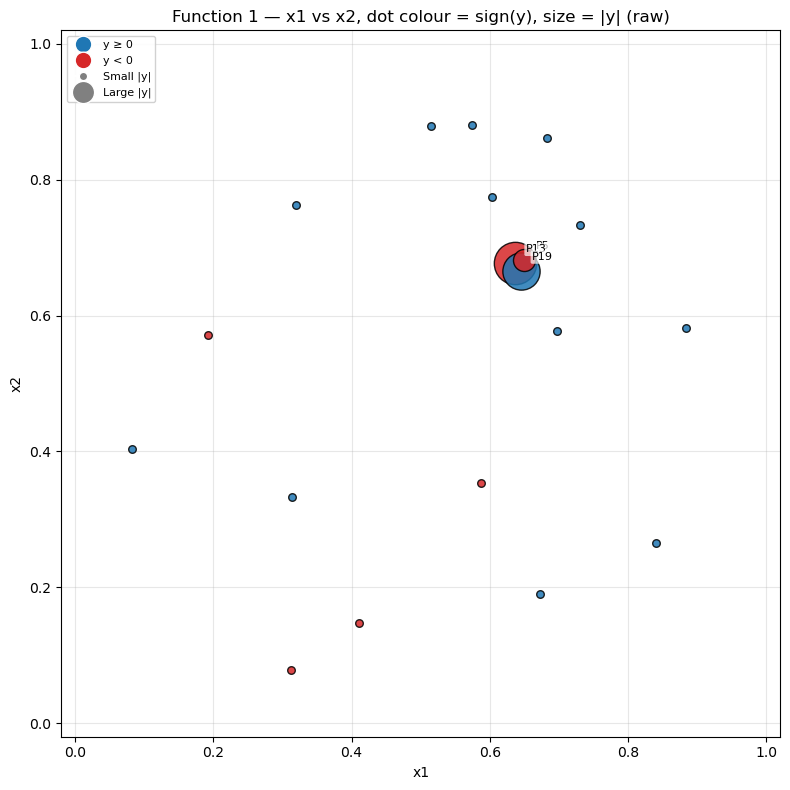

In [20]:
# Plot raw Y values versus X1 (x axis) and X2 (y axis) with magnitude represented by size and sign by colour

labels = [f"P{i+1}" for i in range(len(y))]
colors = np.where(y >= 0, 'tab:blue', 'tab:red')            # sign
sizes = 30 + 900 * (np.abs(y) / np.abs(y).max())            # magnitude

# Draw largest markers first, smallest last, so small markers aren't
# hidden underneath nearby large ones (e.g. P5 next to P13, 0.0146 apart)
order = np.argsort(-sizes)

fig, ax = plt.subplots(figsize=(8, 8))
for i in order:
    ax.scatter(X[i, 0], X[i, 1], c=colors[i], s=sizes[i], alpha=0.85,
               edgecolors='k', linewidths=1.0, zorder=3)

for i, (x1, x2) in enumerate(X):
    if np.abs(y[i]) > 1e-4:  # only label points with meaningful signal
        ax.annotate(labels[i], (x1, x2), textcoords="offset points", xytext=(8, 8), fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, ec='none'))

legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=12, label='y ≥ 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=12, label='y < 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=6, label='Small |y|'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=16, label='Large |y|'),
]
ax.legend(handles=legend_elems, loc='upper left', fontsize=8, framealpha=0.9)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_title('Function 1 — x1 vs x2, dot colour = sign(y), size = |y| (raw)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Transform Data

In [21]:
# As of Week 10 the transformation of Y has been removed to simply use raw y and objective to maximise its value

y_fit = y 
print("Y Fit: ", y_fit)

df_y = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "y": y,
})

output_file = f'./Data/{function}/y_transformations.csv'
df_y.to_csv(output_file, index=False)

Y Fit:  [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  9.65105506e-015  1.04225534e-053
 -1.46411443e-002 -7.30717517e-053 -4.67467649e-023  7.70727219e-082
  7.47409684e-006  6.61817662e-016  1.12361190e-002]


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_1 — y_fit progression with running best'}, xlabel='Iteration (submission number)', ylabel='y_fit'>)

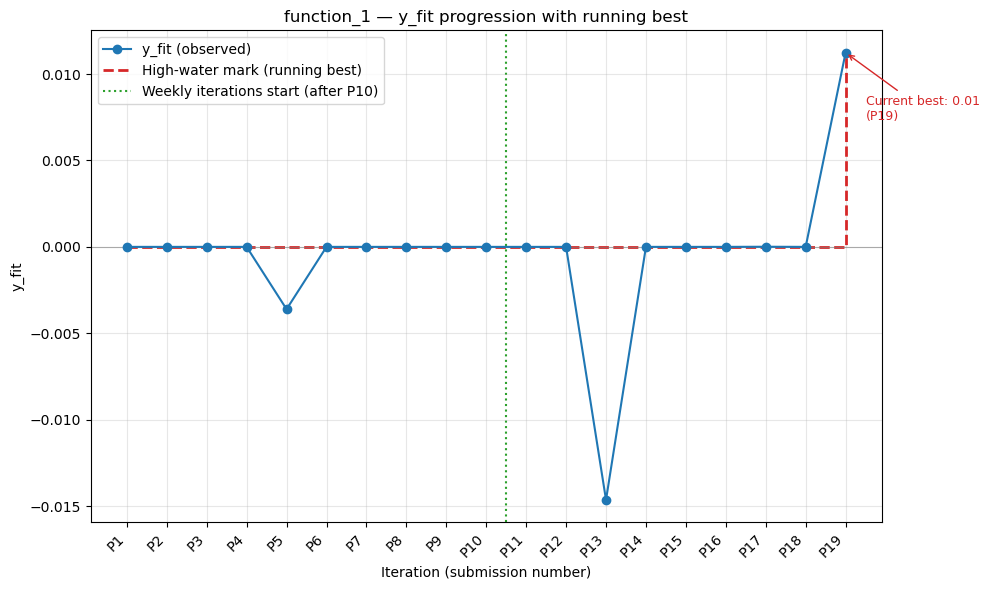

In [22]:
# Point labels and y_fit values to monitor progress
plot_progress(y_fit, labels=None, iteration_start=10, maximize=True,
                   objective_label="y_fit", function_name=function,
                   save_path=None)

## 4. Fit Data to Kernel

In [24]:
# Compare alternative kernels

kernels = {
    'Matern_2.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5),
    'Matern_1.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5),
    'Matern_0.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=0.5),
    'RBF':        ConstantKernel(1.0, (0.01, 10)) * RBF(length_scale=0.3, length_scale_bounds=(0.05, 2.0)),
    'RationalQuadratic': ConstantKernel(1.0, (0.01, 10)) * RationalQuadratic(
        length_scale=0.3, alpha=1.0,
        length_scale_bounds=(0.05, 2.0), alpha_bounds=(0.01, 100)
        ),
    'TwoScale_Matern': ( # NOTE: diagnosed degenerate under loosened bounds (2026-08) — both components collapse to interpolation. AIC win is an artefact, not real structure.
        ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.05, length_scale_bounds=(0.02, 0.1), nu=0.5)
        + ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.1, 2.0), nu=2.5)
        ),
}

for name, k in kernels.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", category=ConvergenceWarning)
        gpr_test = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=20, random_state=42)
        gpr_test.fit(X, y_fit)
    k_fitted = gpr_test.kernel_
    lml = gpr_test.log_marginal_likelihood_value_
    n_params = len(k_fitted.theta)
    aic = -2 * lml + 2 * n_params
    bic = -2 * lml + n_params * np.log(len(y))
    pinned = "  [PINNED: " + "; ".join(str(warn.message).split(".")[0] for warn in w) + "]" if w else ""
    print(f"{name:18s}  LML={lml:.4f}  AIC={aic:.4f}  BIC={bic:.4f}  kernel={k_fitted}{pinned}")

Matern_2.5          LML=-51.5175  AIC=107.0350  BIC=108.9239  kernel=3.16**2 * Matern(length_scale=0.05, nu=2.5)  [PINNED: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10; The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0]
Matern_1.5          LML=-47.5552  AIC=99.1104  BIC=100.9993  kernel=3.16**2 * Matern(length_scale=0.05, nu=1.5)  [PINNED: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10; The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0]
Matern_0.5          LML=-38.6768  AIC=81.3536  BIC=83.2425  kernel=1.95**2 * Matern(length_scale=0.05, nu=0.5)  [PINNED: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0]
RBF                 LML=-60.4456  AIC=124.8911  BIC=126.7800  kernel=3.16

## Definition of terms from kernel fitting

- **Amplitude (signal variance, σ²)** — a prior belief, fixed once fitting is done; the fitted amplitude, expressed in standardized units. Controls how much the function is allowed to vary overall; sets the ceiling on covariance between two identical points. "how much do I believe function values vary across the whole domain, before I've seen where I am relative to any data?" A high amplitude means the model believes the underlying function has a wide range (big peaks, big troughs are plausible)

- **Length-scale (ℓ)** — controls how far correlation extends in input space. Two points closer than ~ℓ apart are treated as strongly correlated; much farther than ℓ apart, correlation decays toward zero and the GP's prediction reverts to the prior mean.

- **ν (nu) — smoothness parameter** — the exponent controlling how smooth the underlying function is assumed to be. ν=0.5 is the special case where the kernel reduces to a pure exponential decay.

- **Predictive uncertainty (σ)** —is posterior, and varies point-to-point. Near an observed point, this uncertainty shrinks toward the (small) noise floor, because the model has direct evidence there. Far from any observed point — beyond the length scale's reach — uncertainty grows back up toward the amplitude, because with no nearby evidence, the model's best guess reverts to its prior belief about how much things vary. amplitude is the ceiling that predictive uncertainty grows toward

## Interpreting fitting metrics
- **LML Log Marginal Likelihood** - how well the fitted kernel explains the observed data, in probability terms; less negative is better fit. Does not account for kernels having different numbers of free parameters, and higher params enables overfitting and lower LML

For AIC and BIC, lower is better
- **AIC = -2 * LML + 2k** : 
- **BIC = -2 * LML + k * ln(n)** :BIC penalizes complexity harder

where k = number of free hyperparameters (2 here: amplitude + length scale — nu is fixed, not fitted), and n = number of data points
The 2k (AIC) and k·ln(n) (BIC) terms are complexity penalties

In [25]:
# Fit Gaussian Process
# Select the best kernel for fitting

#kernel = kernels['Matern_2.5'] #Wk6
#kernel = kernels['RBF'] #Wk6
kernel = kernels['Matern_0.5'] # from week 9

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)
gpr.fit(X, y_fit)
print(gpr.kernel_)

print(f"LML:       {gpr.log_marginal_likelihood_value_:.4f}")

1.95**2 * Matern(length_scale=0.05, nu=0.5)
LML:       -38.6768


C:\Users\scbar\anaconda3\envs\scipy-clean\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## 5. Define Acquisition Function

In [26]:
# --- F1 EI acquisition (corrected objective: raw y maximisation, incumbent P19) ---

np.random.seed(42)

xi = 0.05 * (y.max() - y.min())      # Set Xi to a scale appropriate for the range of Y raw values

# Candidates: domain-wide, not disc-restricted around P13.
# P13 is no longer the region of interest (it's the worst observed point
# under raw-y maximisation), so there's no reason to anchor sampling geometry
# to it. Boundary margin and min_dist match the convention used elsewhere.

n_cand = 10_000
X_candidates = np.random.uniform(0.05, 0.95, size=(n_cand, X.shape[1]))

# Exclusion: minimum distance from ALL existing points
d_min = np.min(np.linalg.norm(X_candidates[:, None, :] - X[None, :, :], axis=2), axis=1)
X_candidates = X_candidates[d_min >= 0.02]
print(f"Candidates after min_dist filter: {len(X_candidates)}")

mu, sigma = gpr.predict(X_candidates, return_std=True)

y_best = np.max(y)          # incumbent is now P19, found automatically — no hardcoding
improvement = mu - y_best - xi
Z = np.where(sigma > 0, improvement / sigma, 0.0)
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

next_idx = int(np.argmax(ei))
next_x = X_candidates[next_idx]

print(f"Incumbent y: {y_best:.6f}")
print(f"Next point to evaluate: {next_x}")
print(f"Formatted: {next_x[0]:.6f}-{next_x[1]:.6f}")
print(f"EI: {ei[next_idx]:.6f}")
print(f"Predicted mean: {mu[next_idx]:.4f}")
print(f"Predicted std: {sigma[next_idx]:.4f}")
print(f"Improvement term: {improvement[next_idx]:.4f}")

assert ei[next_idx] > 0, "EI degenerate — all candidates have zero EI"
assert mu[next_idx] < 1.5 * np.max(y), "Predicted mean implausibly exceeds observed range — check kernel fit"

Candidates after min_dist filter: 9719
Incumbent y: 0.011236
Next point to evaluate: [0.66476262 0.64465465]
Formatted: 0.664763-0.644655
EI: 0.000597
Predicted mean: 0.0060
Predicted std: 0.0068
Improvement term: -0.0065


## 6. Plots for Uncertainty and Signal Strength 

In [27]:
# --- Prediction grid for plotting--

n_grid = 200
x1g, x2g = np.meshgrid(np.linspace(0, 1, n_grid), np.linspace(0, 1, n_grid))
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

# --- Plotting surface (visualisation only) ---
mu_grid, sigma_grid = gpr.predict(X_grid, return_std=True)
mu_grid = mu_grid.reshape(n_grid, n_grid)
sigma_grid = sigma_grid.reshape(n_grid, n_grid)




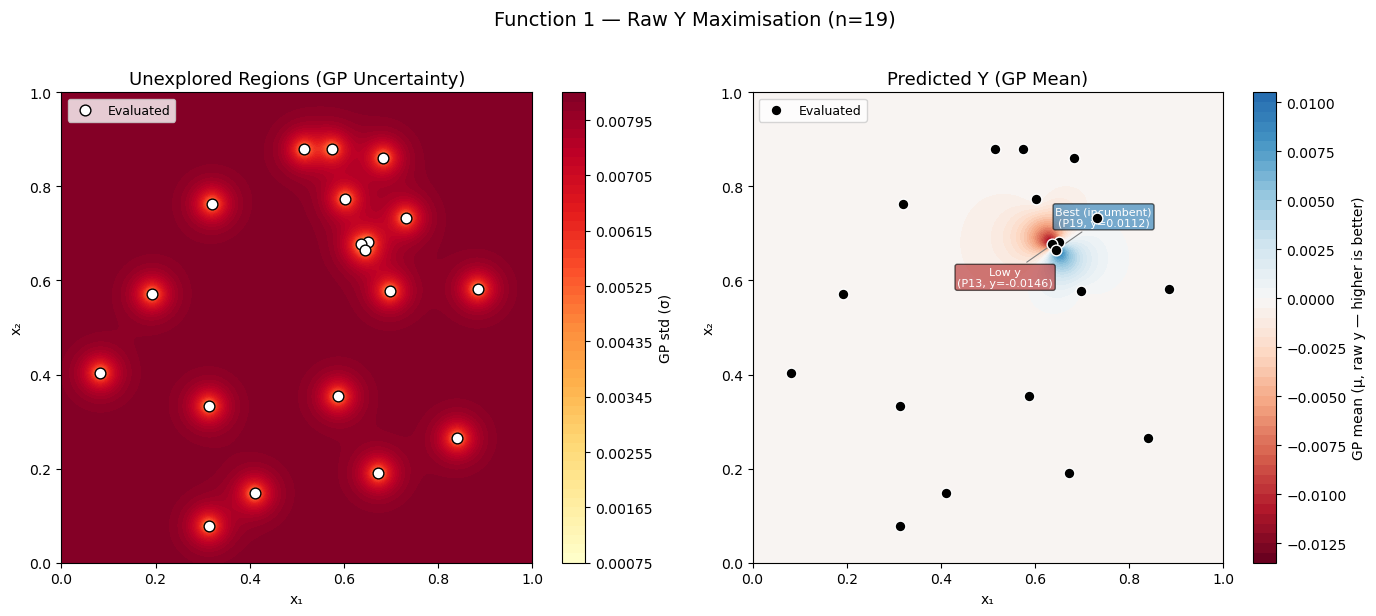

In [29]:
# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Uncertainty (unchanged — still a valid diagnostic regardless of objective)
im1 = axes[0].contourf(x1g, x2g, sigma_grid, levels=50, cmap='YlOrRd')
axes[0].scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=60, zorder=5, label='Evaluated')
plt.colorbar(im1, ax=axes[0], label='GP std (σ)')
axes[0].set_title('Unexplored Regions (GP Uncertainty)', fontsize=13)
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')
axes[0].legend(loc='upper left', fontsize=9)

# Panel 2: Mean prediction in raw-y space (diverging — blue = higher y, red = lower y)
vmax = np.abs(mu_grid).max()
im2 = axes[1].contourf(x1g, x2g, mu_grid, levels=50, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1].scatter(X[:, 0], X[:, 1], c='black', edgecolors='white', s=60, zorder=5, label='Evaluated')

# Annotations: dynamically label the current best (incumbent) and worst observed
# points, rather than hardcoded "source/anti-source" labels — that framing no
# longer applies under raw-y maximisation. Labels are driven by the actual data,
# so they stay correct automatically as new points are appended each cycle.
def label_point(ax, xy, text, fc, dx=0.0, dy=0.07):
    ax.annotate(text, xy=xy, xytext=(xy[0] + dx, xy[1] + dy),
                fontsize=8, color='white', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc=fc, alpha=0.6),
                arrowprops=dict(arrowstyle='-', color='grey', lw=0.8))

labels_all = [f"P{i+1}" for i in range(len(y))]

# Label the top-N highest and lowest raw-y points, found dynamically
n_label = 1
top_idx = np.argsort(-y)[:n_label]     # highest y — good candidates / near incumbent
bottom_idx = np.argsort(y)[:n_label]   # lowest y — worst region, useful context

for rank, i in enumerate(top_idx):
    tag = 'Best (incumbent)' if i == np.argmax(y) else 'High y'
    label_point(axes[1], (X[i, 0], X[i, 1]), f'{tag}\n({labels_all[i]}, y={y[i]:.4f})',
                'tab:blue', dx=0.10 if rank % 2 == 0 else -0.10, dy=0.07)

for rank, i in enumerate(bottom_idx):
    label_point(axes[1], (X[i, 0], X[i, 1]), f'Low y\n({labels_all[i]}, y={y[i]:.4f})',
                'firebrick', dx=-0.10 if rank % 2 == 0 else 0.10, dy=-0.07)

plt.colorbar(im2, ax=axes[1], label='GP mean (μ, raw y — higher is better)')
axes[1].set_title('Predicted Y (GP Mean)', fontsize=13)
axes[1].set_xlabel('x₁'); axes[1].set_ylabel('x₂')
axes[1].legend(loc='upper left', fontsize=9)

plt.suptitle(f'Function 1 — Raw Y Maximisation (n={len(y)})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('./Figures/Function1_exploration_signal.png', dpi=150, bbox_inches='tight')
plt.show()